<a href="https://colab.research.google.com/github/vijaydevverse/ML-DL-Projects-Portfolio/blob/main/AI_Powered_Employee_Attrition_Prediction_using_Machine_Learning_%26_Generative_AI_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

With `Attrition` as the prediction variable, the task involves using other features in the dataset to predict whether an employee is likely to leave the organization or stay. This can be approached as a binary classification problem, where the model learns patterns from employee demographic details, technical skills, work environment, salary, performance, and AI tool usage to predict the likelihood of employee attrition (`Yes` or `No`).

Employee attrition is one of the major challenges faced by IT industries and technology-driven organizations. High attrition rates can lead to increased recruitment costs, reduced productivity, knowledge loss, and project delays. Early identification of employees who are at risk of leaving can help organizations take proactive measures to improve employee satisfaction, retention, and overall workforce stability. In this project, we aim to develop a predictive model that leverages employee-related information such as experience, technical skills, work hours, salary, training, remote work preferences, project types, and AI tool usage to determine the likelihood of employee attrition.

The objective is to predict employee attrition (`Attrition`) based on a range of professional, behavioral, and workplace-related features including employee experience, job role, project type, work hours, performance score, salary, AI tools used, training hours, remote work status, and promotion history. This predictive model can assist IT companies and HR departments in identifying high-risk employees, improving retention strategies, enhancing employee engagement, and supporting better workforce management decisions.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
df=pd.read_csv('/content/ML_GenerativeAI_IT_Industry_Datase.csv')
df

,Employee_ID,Employee_Name,Age,Gender,Company,Job_Role,Experience_Years,Primary_Skill,Secondary_Skill,Project_Type,Performance_Score,AI_Tools_Used,Remote_Work,Work_Hours_Per_Week,Salary_INR,Promotion_Last_2Yrs,Training_Hours,Location,Joining_Date,Attrition
0,EMP000001,Luis Williams,44,Female,Google,Prompt Engineer,3,Kubernetes,Docker,Code Generation AI,1.35,Gemini,Yes,30,500000,Yes,65,Pune,2025-06-01,Stayed
1,EMP000002,Joseph Banks,41,Female,Google,Cybersecurity Analyst,6,Power BI,Python,Customer Segmentation,3.79,Claude,No,34,4900000,Yes,96,Hyderabad,2024-04-04,Left
2,EMP000003,Douglas Mcdonald,48,Female,Capgemini,Cloud Engineer,3,TensorFlow,Computer Vision,Code Generation AI,1.50,Gemini,Yes,47,2600000,No,170,Delhi,2025-08-14,Stayed
3,EMP000004,Cynthia Farmer,42,Male,Microsoft,Data Scientist,2,SQL,Docker,Healthcare Prediction,2.11,Claude,Yes,41,600000,No,63,Mumbai,2025-12-19,Stayed
4,EMP000005,Jason Reyes,44,Male,Wipro,Cybersecurity Analyst,5,Deep Learning,Power BI,Code Generation AI,1.88,Claude,Yes,37,3800000,Yes,90,Kochi,2024-10-01,Stayed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,EMP099996,Erica Singh,23,Male,Infosys,Cloud Engineer,4,Kubernetes,Power BI,Customer Segmentation,3.23,Claude,Hybrid,54,3800000,Yes,114,Hyderabad,2025-02-13,Left
99996,EMP099997,Scott Smith,30,Female,Amazon,MLOps Engineer,12,Machine Learning,Deep Learning,Code Generation AI,4.84,Claude,No,33,4100000,No,60,Kochi,2024-11-08,Left
99997,EMP099998,Sara Cook,35,Female,Infosys,Generative AI Engineer,9,Computer Vision,Hadoop,Recommendation System,1.42,Copilot,Hybrid,34,3400000,No,151,Trivandrum,2024-10-02,Left
99998,EMP099999,Melody Bender,27,Male,Accenture,Software Engineer,1,AWS,Deep Learning,Healthcare Prediction,1.20,ChatGPT,Yes,55,600000,Yes,140,Delhi,2024-06-09,Stayed


In [ ]:
df.head()

,Employee_ID,Employee_Name,Age,Gender,Company,Job_Role,Experience_Years,Primary_Skill,Secondary_Skill,Project_Type,Performance_Score,AI_Tools_Used,Remote_Work,Work_Hours_Per_Week,Salary_INR,Promotion_Last_2Yrs,Training_Hours,Location,Joining_Date,Attrition
0,EMP000001,Luis Williams,44,Female,Google,Prompt Engineer,3,Kubernetes,Docker,Code Generation AI,1.35,Gemini,Yes,30,500000,Yes,65,Pune,2025-06-01,Stayed
1,EMP000002,Joseph Banks,41,Female,Google,Cybersecurity Analyst,6,Power BI,Python,Customer Segmentation,3.79,Claude,No,34,4900000,Yes,96,Hyderabad,2024-04-04,Left
2,EMP000003,Douglas Mcdonald,48,Female,Capgemini,Cloud Engineer,3,TensorFlow,Computer Vision,Code Generation AI,1.50,Gemini,Yes,47,2600000,No,170,Delhi,2025-08-14,Stayed
3,EMP000004,Cynthia Farmer,42,Male,Microsoft,Data Scientist,2,SQL,Docker,Healthcare Prediction,2.11,Claude,Yes,41,600000,No,63,Mumbai,2025-12-19,Stayed
4,EMP000005,Jason Reyes,44,Male,Wipro,Cybersecurity Analyst,5,Deep Learning,Power BI,Code Generation AI,1.88,Claude,Yes,37,3800000,Yes,90,Kochi,2024-10-01,Stayed


In [ ]:
df.tail()

,Employee_ID,Employee_Name,Age,Gender,Company,Job_Role,Experience_Years,Primary_Skill,Secondary_Skill,Project_Type,Performance_Score,AI_Tools_Used,Remote_Work,Work_Hours_Per_Week,Salary_INR,Promotion_Last_2Yrs,Training_Hours,Location,Joining_Date,Attrition
99995,EMP099996,Erica Singh,23,Male,Infosys,Cloud Engineer,4,Kubernetes,Power BI,Customer Segmentation,3.23,Claude,Hybrid,54,3800000,Yes,114,Hyderabad,2025-02-13,Left
99996,EMP099997,Scott Smith,30,Female,Amazon,MLOps Engineer,12,Machine Learning,Deep Learning,Code Generation AI,4.84,Claude,No,33,4100000,No,60,Kochi,2024-11-08,Left
99997,EMP099998,Sara Cook,35,Female,Infosys,Generative AI Engineer,9,Computer Vision,Hadoop,Recommendation System,1.42,Copilot,Hybrid,34,3400000,No,151,Trivandrum,2024-10-02,Left
99998,EMP099999,Melody Bender,27,Male,Accenture,Software Engineer,1,AWS,Deep Learning,Healthcare Prediction,1.20,ChatGPT,Yes,55,600000,Yes,140,Delhi,2024-06-09,Stayed
99999,EMP100000,Bonnie Short,25,Female,Wipro,Cybersecurity Analyst,11,Docker,Hadoop,Customer Segmentation,1.86,Midjourney,Yes,34,1900000,Yes,59,Delhi,2024-01-04,Stayed


In [ ]:
df.shape

(100000, 20)

In [ ]:
df.columns

Index(['Employee_ID', 'Employee_Name', 'Age', 'Gender', 'Company', 'Job_Role',
       'Experience_Years', 'Primary_Skill', 'Secondary_Skill', 'Project_Type',
       'Performance_Score', 'AI_Tools_Used', 'Remote_Work',
       'Work_Hours_Per_Week', 'Salary_INR', 'Promotion_Last_2Yrs',
       'Training_Hours', 'Location', 'Joining_Date', 'Attrition'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Employee_ID          100000 non-null  object 
 1   Employee_Name        100000 non-null  object 
 2   Age                  100000 non-null  int64  
 3   Gender               100000 non-null  object 
 4   Company              100000 non-null  object 
 5   Job_Role             100000 non-null  object 
 6   Experience_Years     100000 non-null  int64  
 7   Primary_Skill        100000 non-null  object 
 8   Secondary_Skill      100000 non-null  object 
 9   Project_Type         100000 non-null  object 
 10  Performance_Score    100000 non-null  float64
 11  AI_Tools_Used        100000 non-null  object 
 12  Remote_Work          100000 non-null  object 
 13  Work_Hours_Per_Week  100000 non-null  int64  
 14  Salary_INR           100000 non-null  int64  
 15  Promotion_Last_2Yr

In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Employee_Name,0
Age,0
Gender,0
Company,0
Job_Role,0
Experience_Years,0
Primary_Skill,0
Secondary_Skill,0
Project_Type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target='Attrition'

In [ ]:
df[target].value_counts()

,count
Attrition,
Stayed,50268
Left,49732


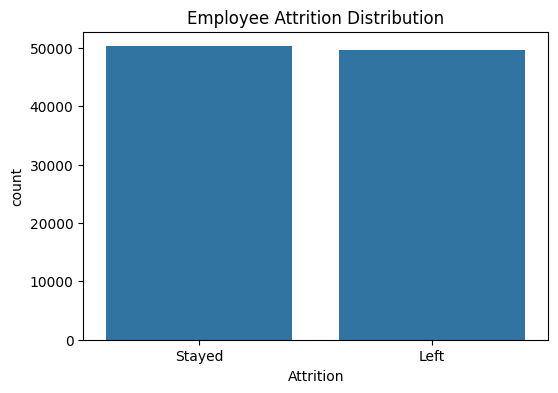

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=target,data=df)
plt.title("Employee Attrition Distribution")
plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

Index(['Employee_ID', 'Employee_Name', 'Gender', 'Company', 'Job_Role',
       'Primary_Skill', 'Secondary_Skill', 'Project_Type', 'AI_Tools_Used',
       'Remote_Work', 'Promotion_Last_2Yrs', 'Location', 'Joining_Date',
       'Attrition'],
      dtype='object')

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['Age', 'Experience_Years', 'Performance_Score', 'Work_Hours_Per_Week',
       'Salary_INR', 'Training_Hours'],
      dtype='object')

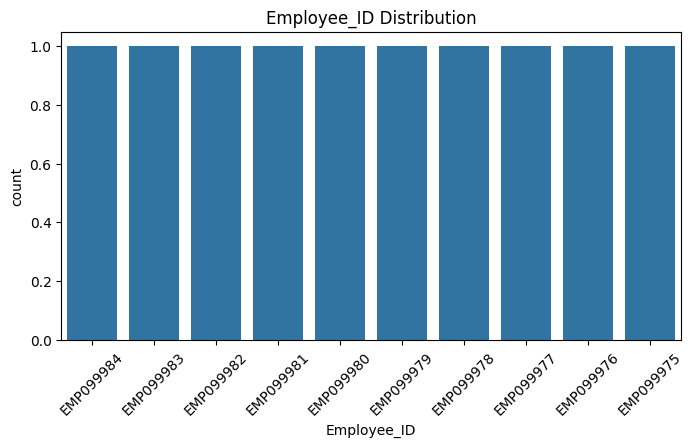

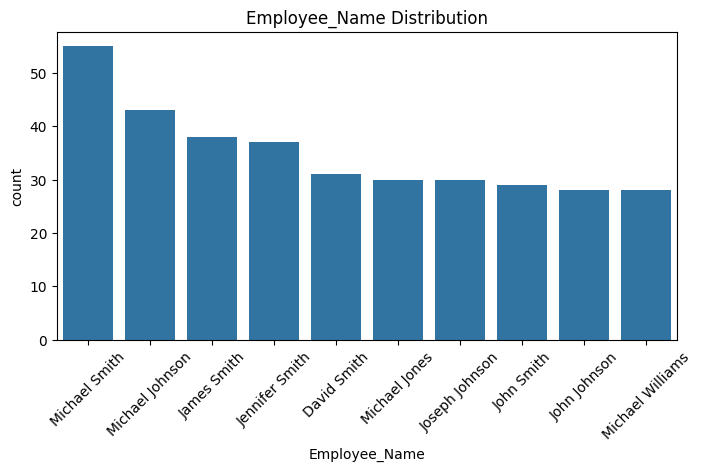

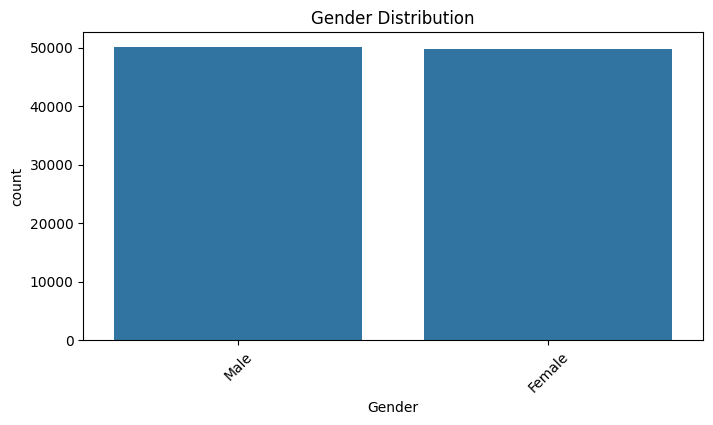

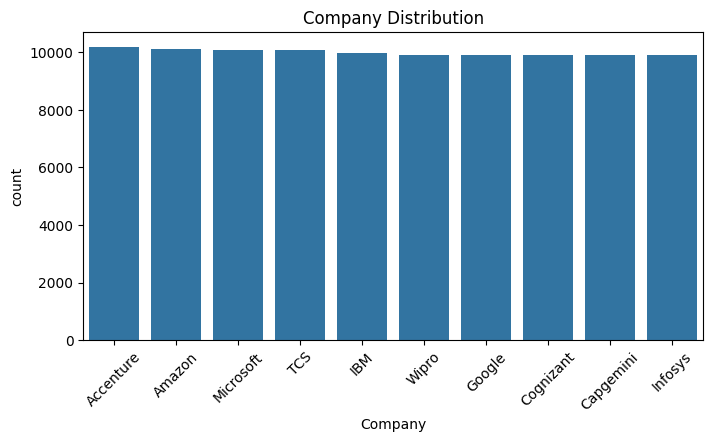

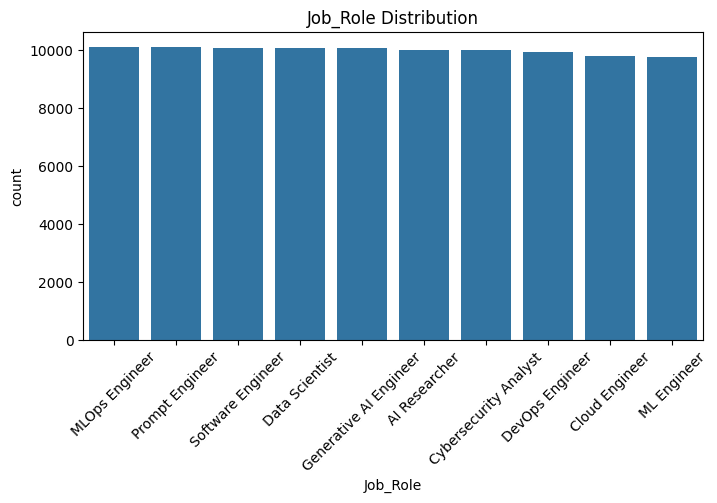

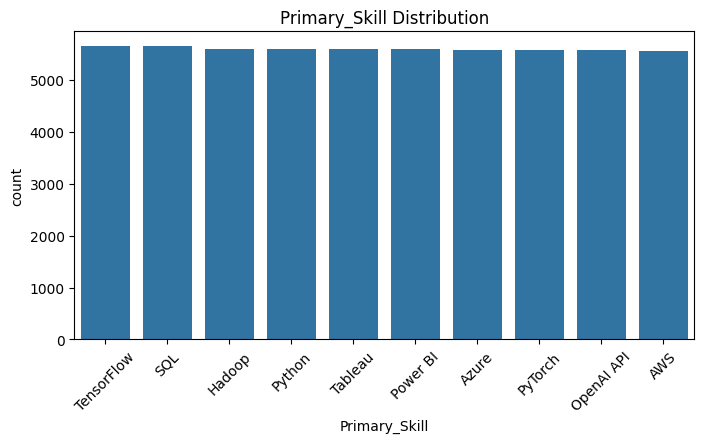

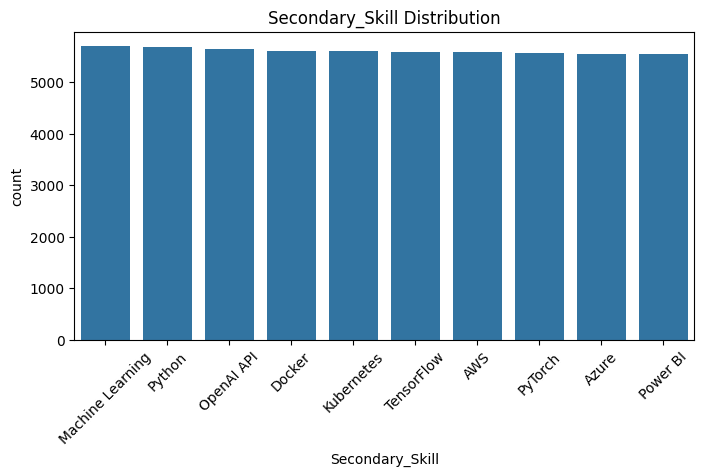

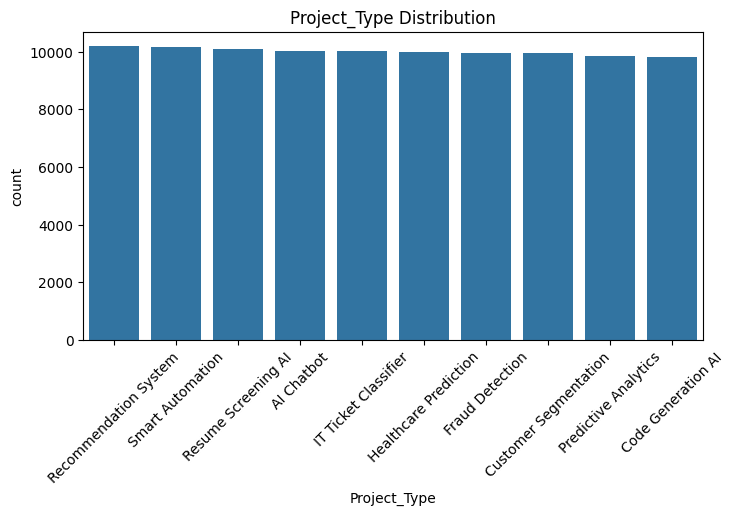

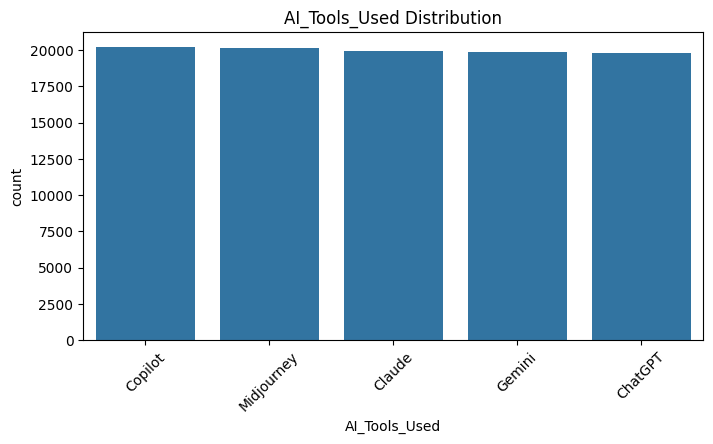

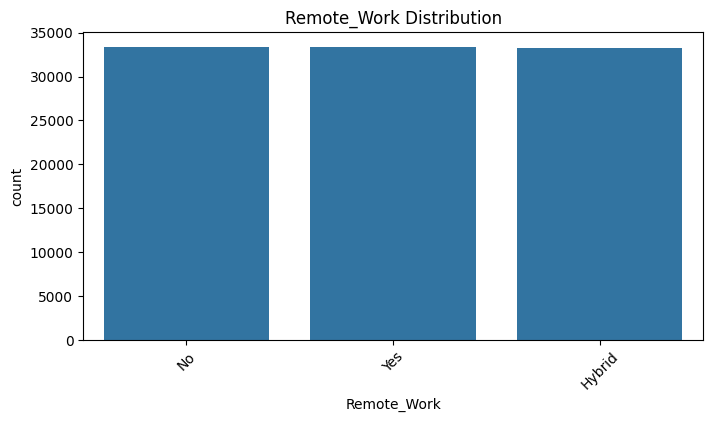

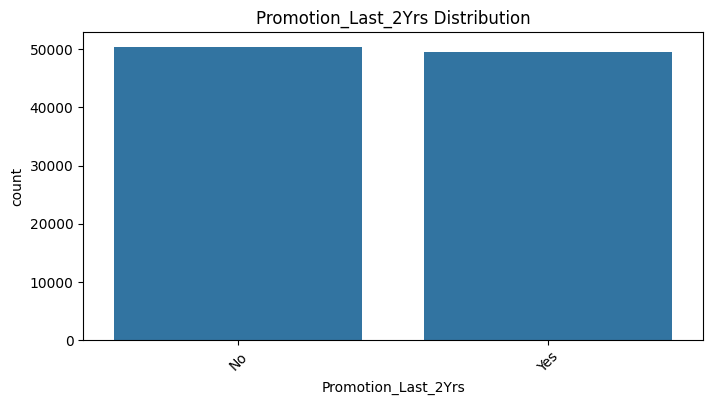

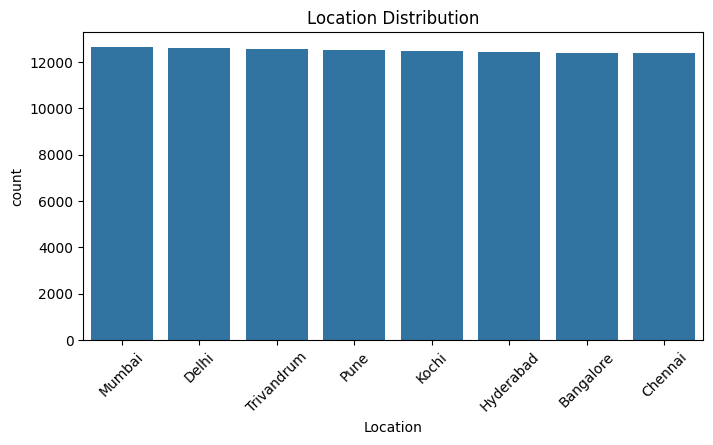

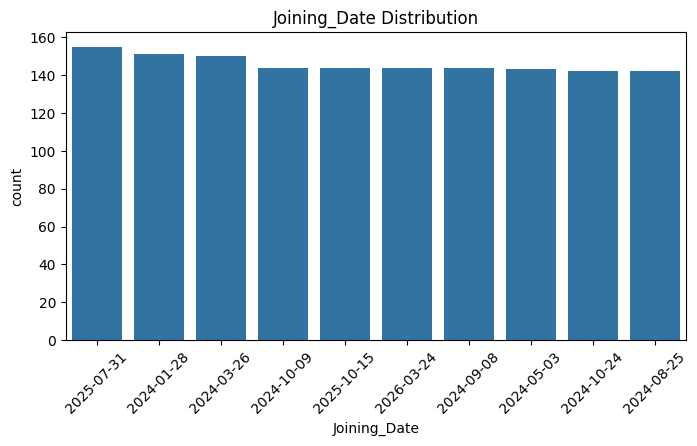

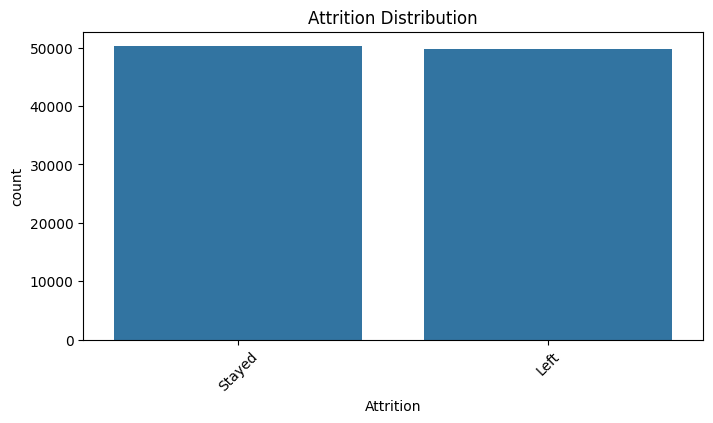

In [ ]:
for col in categorical_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        x=df[col],
        order=df[col].value_counts().index[:10])

    plt.xticks(rotation=45)
    plt.title(f'{col} Distribution')
    plt.show()

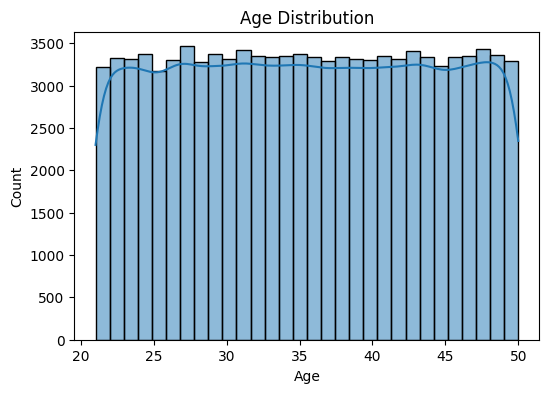

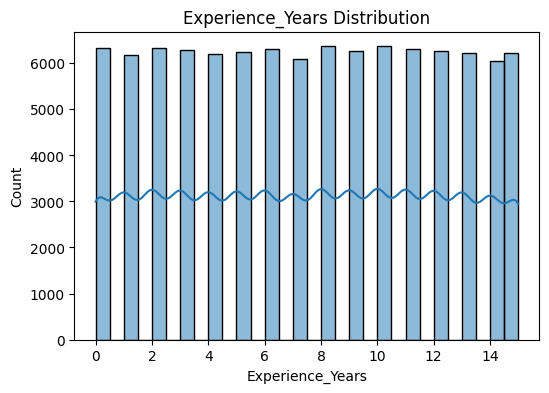

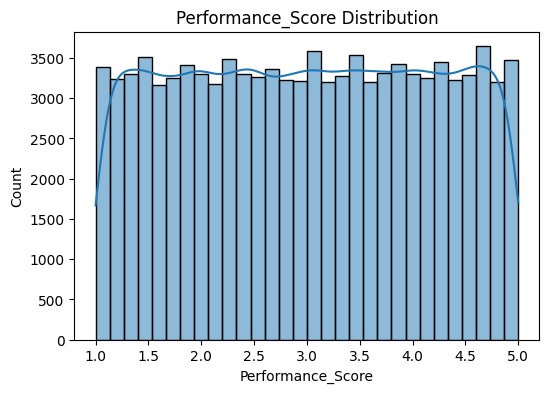

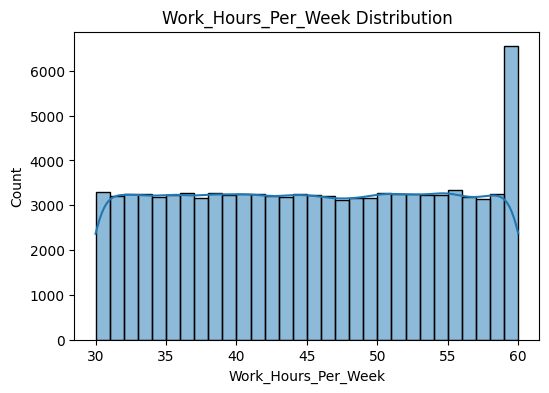

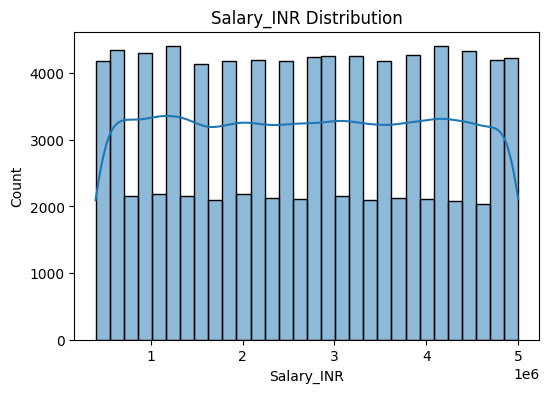

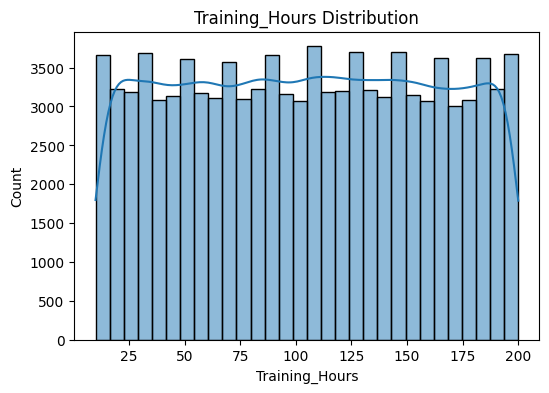

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col],bins=30,kde=True)

    plt.title(f'{col} Distribution')
    plt.show()

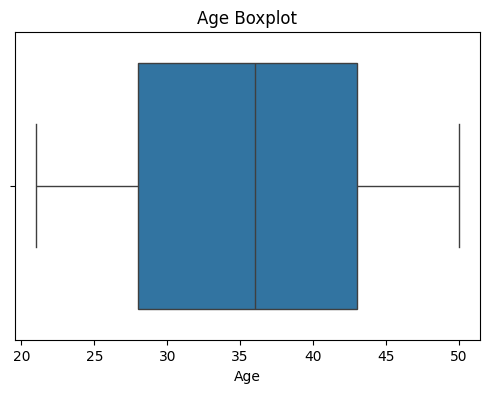

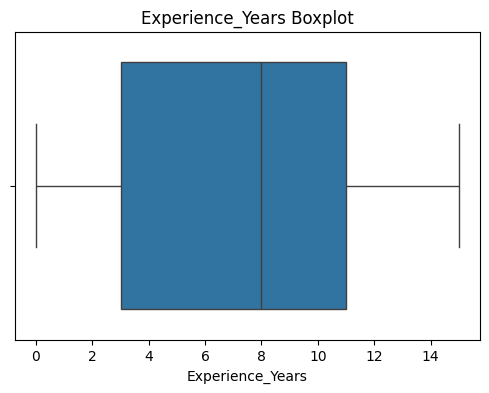

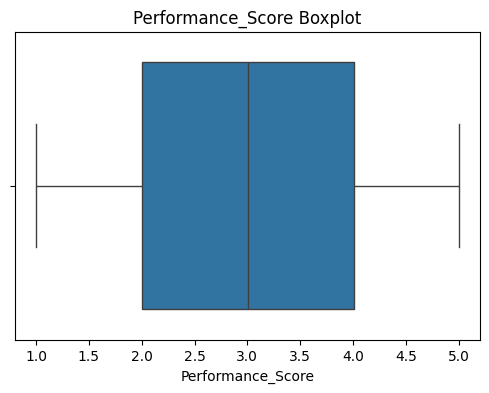

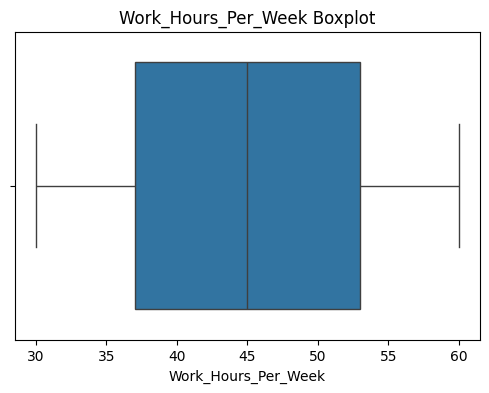

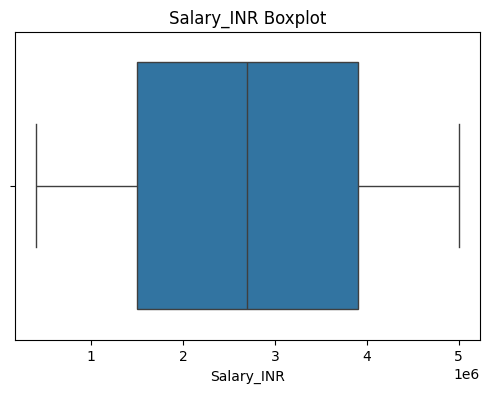

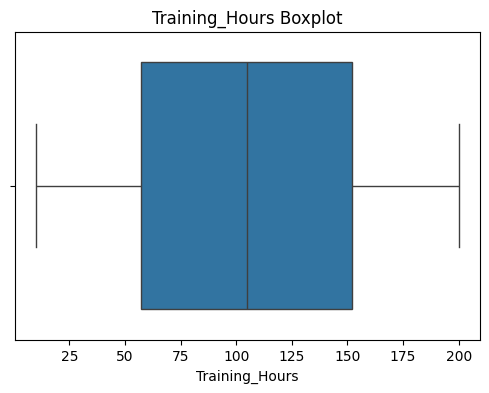

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f'{col} Boxplot')
    plt.show()

In [ ]:
le=LabelEncoder()

for col in categorical_cols:

    df[col]=le.fit_transform(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Employee_ID          100000 non-null  int64  
 1   Employee_Name        100000 non-null  int64  
 2   Age                  100000 non-null  int64  
 3   Gender               100000 non-null  int64  
 4   Company              100000 non-null  int64  
 5   Job_Role             100000 non-null  int64  
 6   Experience_Years     100000 non-null  int64  
 7   Primary_Skill        100000 non-null  int64  
 8   Secondary_Skill      100000 non-null  int64  
 9   Project_Type         100000 non-null  int64  
 10  Performance_Score    100000 non-null  float64
 11  AI_Tools_Used        100000 non-null  int64  
 12  Remote_Work          100000 non-null  int64  
 13  Work_Hours_Per_Week  100000 non-null  int64  
 14  Salary_INR           100000 non-null  int64  
 15  Promotion_Last_2Yr

In [ ]:
x=df.drop('Attrition',axis=1)
y=df['Attrition']

smote=SMOTE(random_state=42)

x_resampled,y_resampled=smote.fit_resample(x,y)

df_resampled=pd.concat(
    [
        pd.DataFrame(x_resampled,columns=x.columns),
        pd.DataFrame(y_resampled,columns=['Attrition'])
    ],
    axis=1)

print(df_resampled.head())

print(df_resampled['Attrition'].value_counts())

df=df_resampled

   Employee_ID  Employee_Name  Age  Gender  Company  Job_Role  \
0            0          44211   44       0        4         8   
1            1          34582   41       0        4         2   
2            2          20535   48       0        2         1   
3            3          15938   42       1        7         3   
4            4          29434   44       1        9         2   

   Experience_Years  Primary_Skill  Secondary_Skill  Project_Type  \
0                 3              6                4             1   
1                 6             11               13             2   
2                 3             17                2             1   
3                 2             14                4             4   
4                 5              3               11             1   

   Performance_Score  AI_Tools_Used  Remote_Work  Work_Hours_Per_Week  \
0               1.35              3            2                   30   
1               3.79              1            1

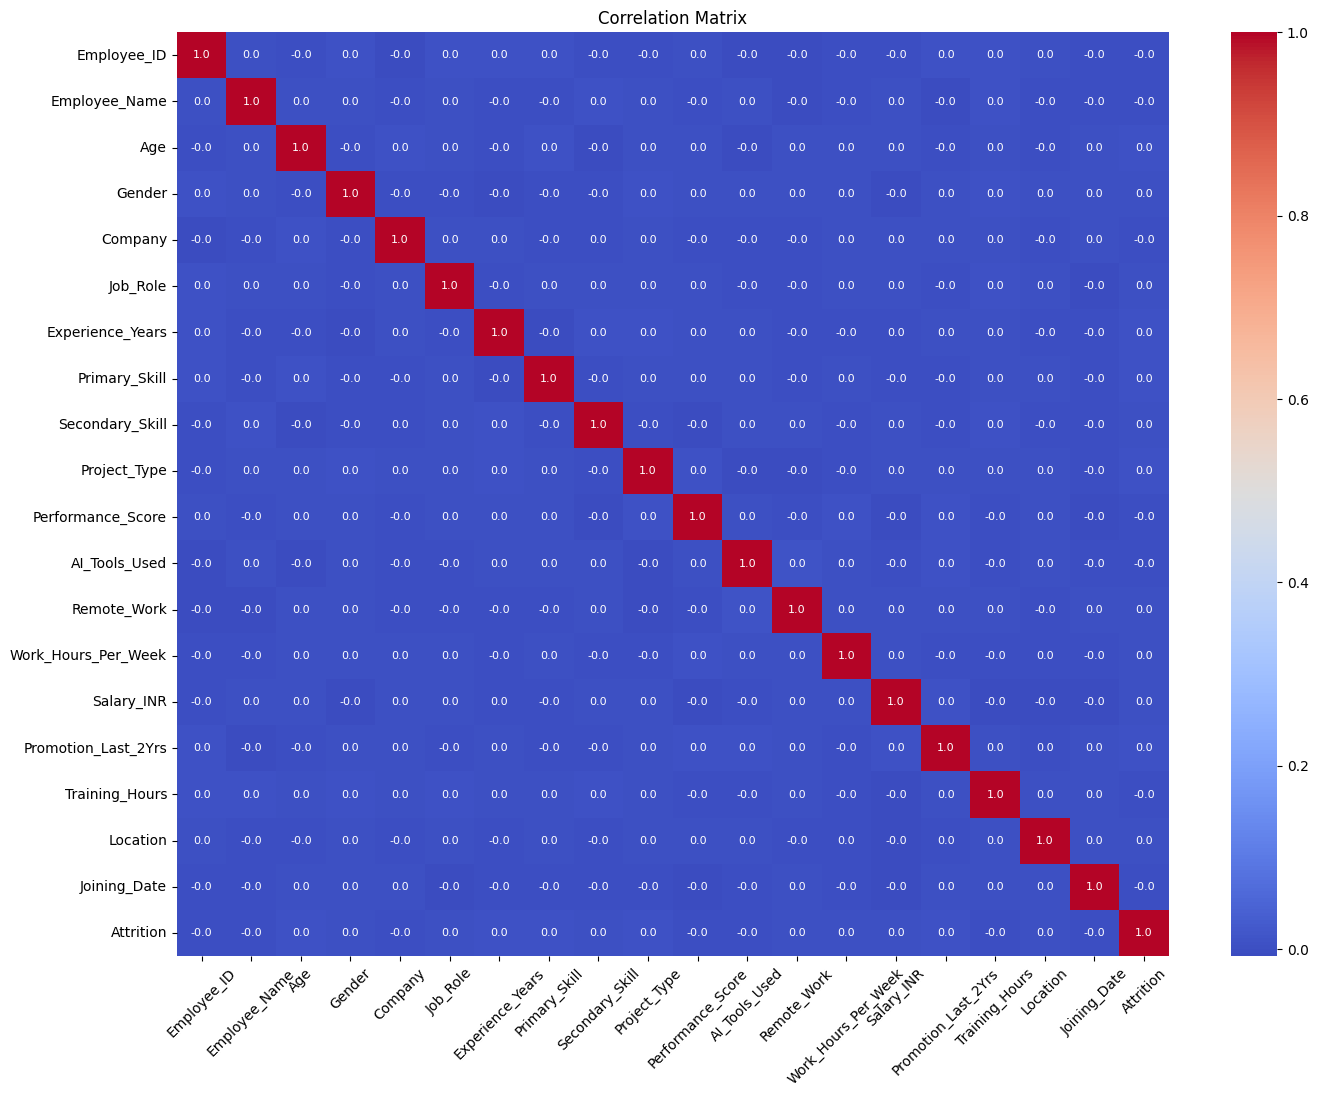

In [ ]:
plt.figure(figsize=(16,12))

cm=df.corr(numeric_only=True)

sns.heatmap(
    cm,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    annot_kws={"size":8})

plt.title("Correlation Matrix")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.show()

In [ ]:
corr=df.corr(numeric_only=True)[target]

corr=corr.drop(target)

corr

,Attrition
Employee_ID,-0.000081
Employee_Name,-0.001530
Age,0.004689
Gender,0.001930
Company,-0.000245
Job_Role,0.000447
Experience_Years,0.006424
Primary_Skill,0.004630
Secondary_Skill,0.000585
Project_Type,0.005687


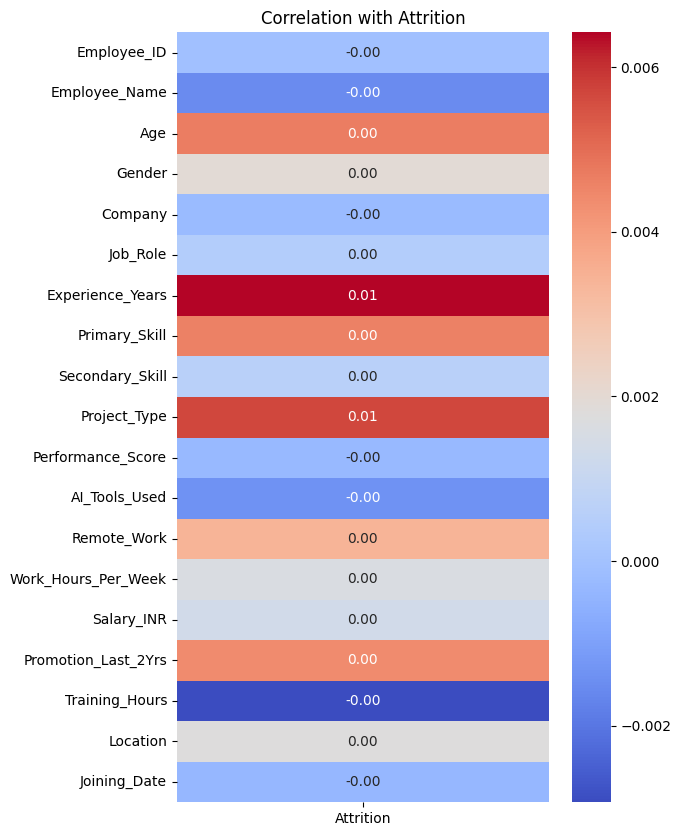

In [ ]:
plt.figure(figsize=(6,10))

sns.heatmap(
    corr.to_frame(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar=True)

plt.title('Correlation with Attrition')

plt.show()

In [ ]:
top_corr=corr.sort_values(ascending=False)

top_corr

,Attrition
Experience_Years,0.006424
Project_Type,0.005687
Age,0.004689
Primary_Skill,0.004630
Promotion_Last_2Yrs,0.004397
Remote_Work,0.003414
Gender,0.001930
Location,0.001761
Work_Hours_Per_Week,0.001634
Salary_INR,0.001313


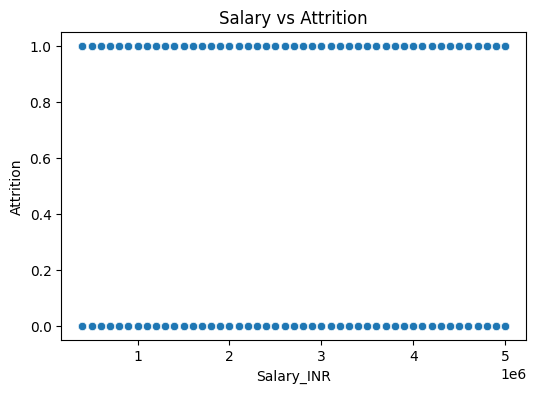

In [ ]:
if 'Salary_INR' in df.columns:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x='Salary_INR',
        y=target,
        data=df)

    plt.title("Salary vs Attrition")

    plt.show()

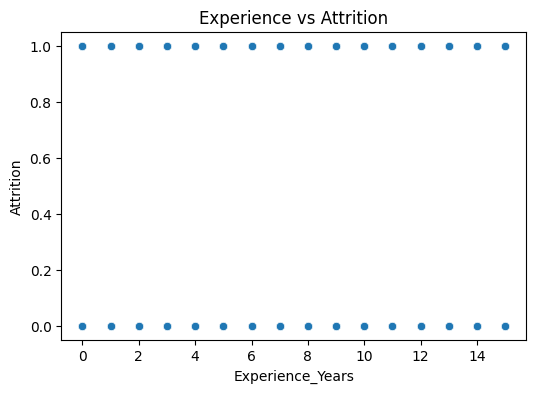

In [ ]:
if 'Experience_Years' in df.columns:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x='Experience_Years',
        y=target,
        data=df)

    plt.title("Experience vs Attrition")

    plt.show()

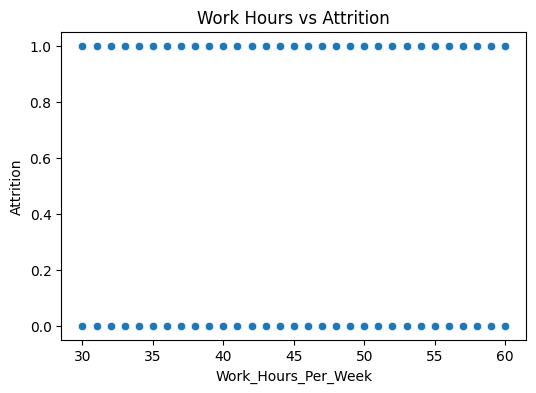

In [ ]:
if 'Work_Hours_Per_Week' in df.columns:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x='Work_Hours_Per_Week',
        y=target,
        data=df)

    plt.title("Work Hours vs Attrition")

    plt.show()

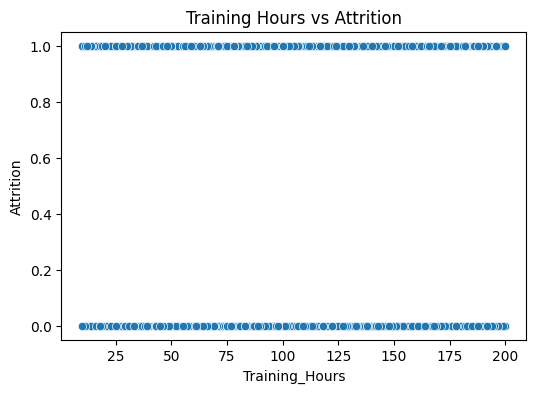

In [ ]:
if 'Training_Hours' in df.columns:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x='Training_Hours',
        y=target,
        data=df)

    plt.title("Training Hours vs Attrition")

    plt.show()

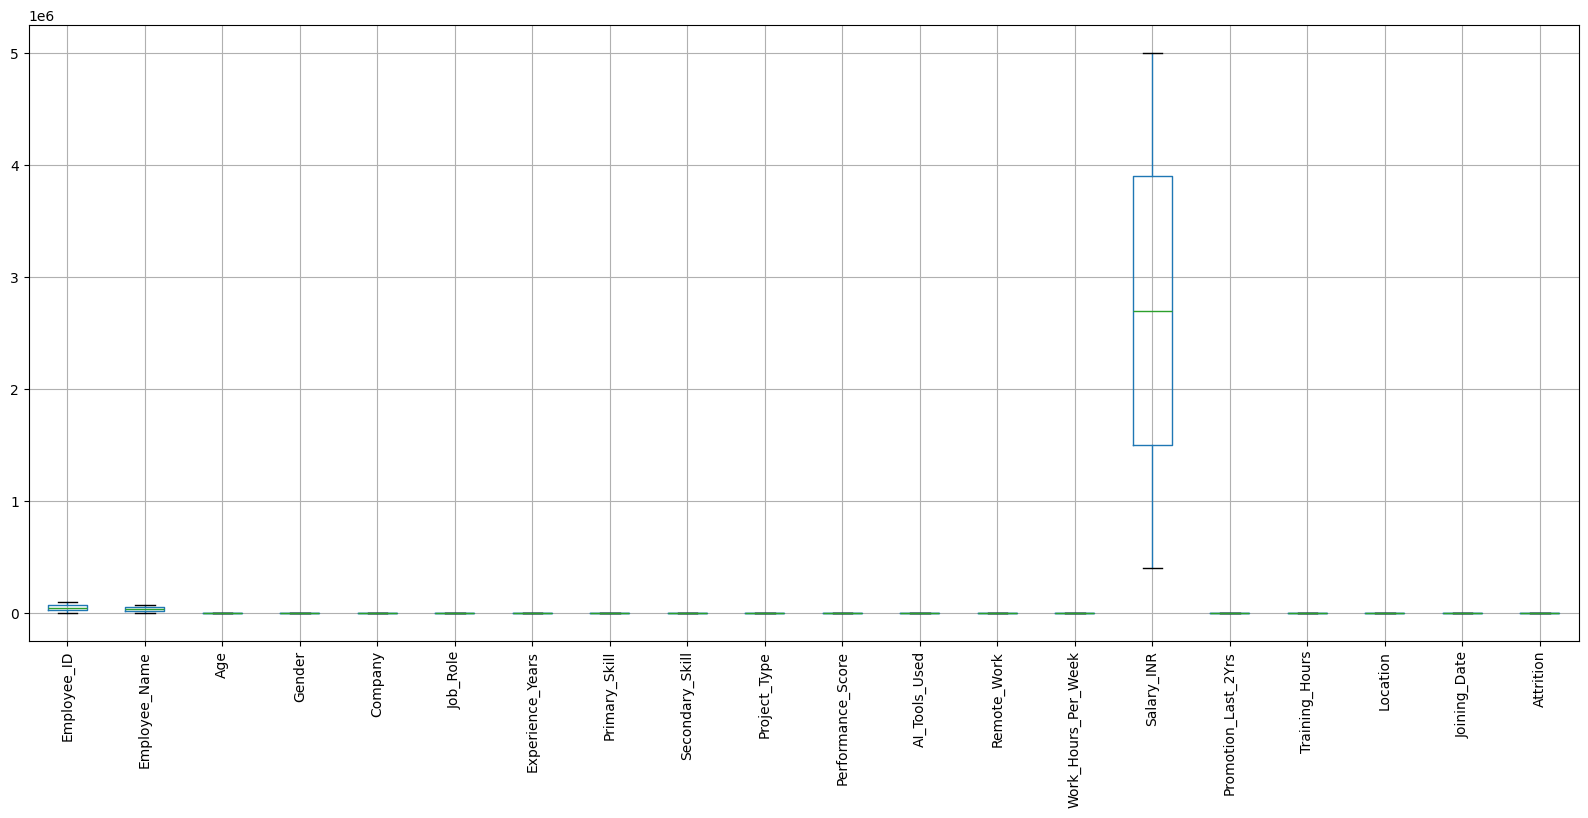

In [ ]:
df.boxplot(figsize=(20,8))

plt.xticks(rotation=90)

plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):

    for col in df.select_dtypes(include=['int64','float64']).columns:

        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)

        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[
            (df[col]>=lower) &
            (df[col]<=upper)
        ]

    return df

df=remove_outliers_iqr(df,exclude_column=target)

df.shape

(100536, 20)

In [ ]:
features=df.drop(target,axis=1).columns

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(
    scaled_data,
    columns=features)

scaled_df

,Employee_ID,Employee_Name,Age,Gender,Company,Job_Role,Experience_Years,Primary_Skill,Secondary_Skill,Project_Type,Performance_Score,AI_Tools_Used,Remote_Work,Work_Hours_Per_Week,Salary_INR,Promotion_Last_2Yrs,Training_Hours,Location,Joining_Date
0,0.000000,0.620296,0.793103,0.0,0.444444,0.888889,0.200000,0.352941,0.235294,0.111111,0.087500,0.75,1.0,0.000000,0.021739,1.0,0.289474,0.857143,0.608235
1,0.000010,0.485198,0.689655,0.0,0.444444,0.222222,0.400000,0.647059,0.764706,0.222222,0.697500,0.25,0.5,0.133333,0.978261,1.0,0.452632,0.428571,0.110588
2,0.000020,0.288113,0.931034,0.0,0.222222,0.111111,0.200000,1.000000,0.117647,0.111111,0.125000,0.75,1.0,0.566667,0.478261,0.0,0.842105,0.285714,0.695294
3,0.000030,0.223616,0.724138,1.0,0.777778,0.333333,0.133333,0.823529,0.235294,0.444444,0.277500,0.25,1.0,0.366667,0.043478,0.0,0.278947,0.714286,0.844706
4,0.000040,0.412970,0.793103,1.0,1.000000,0.222222,0.333333,0.176471,0.647059,0.111111,0.220000,0.25,1.0,0.233333,0.739130,1.0,0.421053,0.571429,0.322353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100531,0.504585,0.232315,0.724138,0.0,0.555556,0.222222,0.600000,0.470588,0.352941,0.111111,0.425992,0.75,1.0,0.133333,0.652174,0.0,0.268421,0.714286,0.261176
100532,0.580896,0.100640,0.517241,0.0,0.888889,0.333333,0.133333,0.823529,0.529412,0.777778,0.439592,0.25,0.0,0.233333,1.000000,0.0,0.184211,0.428571,0.251765
100533,0.128621,0.804964,0.344828,1.0,0.555556,0.222222,0.466667,0.235294,0.176471,0.555556,0.485255,0.25,0.0,0.566667,0.108696,1.0,0.463158,0.571429,0.932941
100534,0.842508,0.097399,0.448276,0.0,0.666667,0.888889,0.066667,1.000000,0.705882,0.777778,0.522033,0.75,0.0,0.200000,0.000000,0.0,0.831579,0.428571,0.577647


In [ ]:
x=df.drop('Attrition',axis=1)
y=df['Attrition']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
lr_model=LogisticRegression(max_iter=10000)

lr_model.fit(x_train,y_train)

y_pred_lr=lr_model.predict(x_test)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.49757300867351


In [ ]:
dt_model=DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train,y_train)

y_pred_dt=dt_model.predict(x_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test,y_pred_dt))

Decision Tree Accuracy: 0.5022678443542612


In [ ]:
rf_model=RandomForestClassifier(random_state=42)

rf_model.fit(x_train,y_train)

y_pred_rf=rf_model.predict(x_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy: 0.5026259250417761


In [ ]:
gb_model=GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train,y_train)

y_pred_gb=gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",
    accuracy_score(y_test,y_pred_gb))

Gradient Boosting Accuracy: 0.4997612795416567


In [ ]:
ada_model=AdaBoostClassifier(random_state=42)

ada_model.fit(x_train,y_train)

y_pred_ada=ada_model.predict(x_test)

print(
    "AdaBoost Accuracy:",
    accuracy_score(y_test,y_pred_ada))

AdaBoost Accuracy: 0.49868703747911197


In [ ]:
svm_model=SVC(kernel='rbf')

svm_model.fit(x_train,y_train)

y_pred_svm=svm_model.predict(x_test)

print(
    "SVM Accuracy:",
    accuracy_score(y_test,y_pred_svm))

SVM Accuracy: 0.5041776080210074


In [ ]:
xgb_model=XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(x_train,y_train)

y_pred_xgb=xgb_model.predict(x_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test,y_pred_xgb)
)

XGBoost Accuracy: 0.49956234582637066


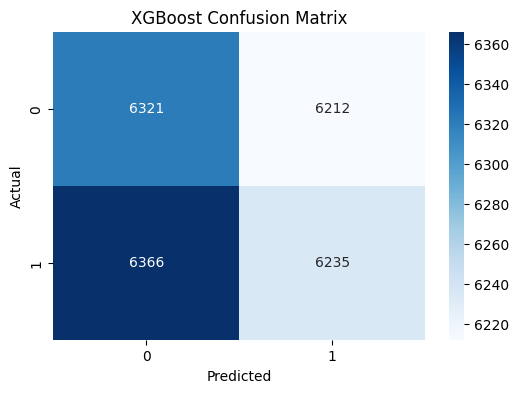

In [ ]:
cm=confusion_matrix(y_test,y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

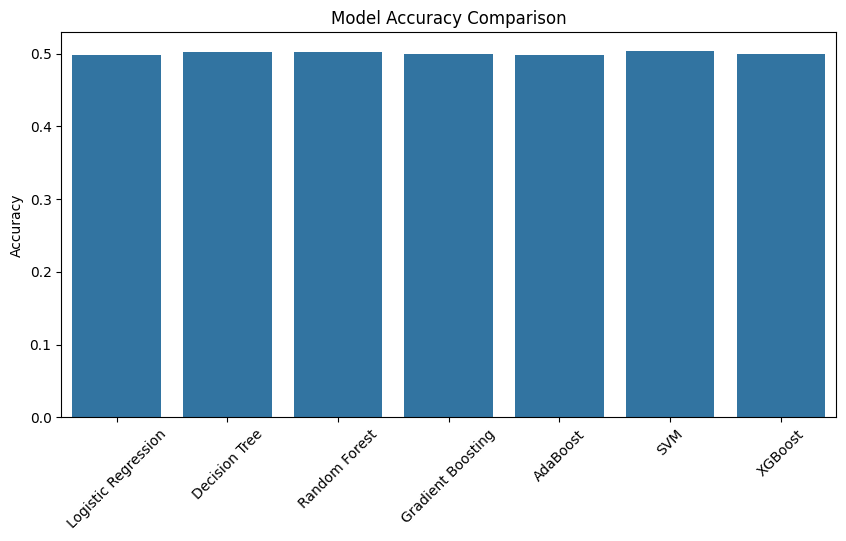

In [ ]:
models=[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost',
    'SVM',
    'XGBoost'
]

accuracies=[
    accuracy_score(y_test,y_pred_lr),
    accuracy_score(y_test,y_pred_dt),
    accuracy_score(y_test,y_pred_rf),
    accuracy_score(y_test,y_pred_gb),
    accuracy_score(y_test,y_pred_ada),
    accuracy_score(y_test,y_pred_svm),
    accuracy_score(y_test,y_pred_xgb)
]

plt.figure(figsize=(10,5))

sns.barplot(
    x=models,
    y=accuracies
)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

**K-Fold Cross Validation**

In [ ]:
X=df.drop('Attrition',axis=1)
y=df['Attrition']

kf=KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model=LogisticRegression(max_iter=10000)

best_accuracy=0

best_fold=-1

best_X_train=None
best_y_train=None
best_X_test=None
best_y_test=None
best_y_pred=None

In [ ]:
for fold,(train_index,test_index) in enumerate(kf.split(X),1):

    print(f"\nFold {fold}")

    X_train,X_test=X.iloc[train_index],X.iloc[test_index]

    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc

        best_fold=fold

        best_X_train=X_train
        best_y_train=y_train

        best_X_test=X_test
        best_y_test=y_test

        best_y_pred=y_pred


Fold 1
Accuracy: 0.4985577879450965

Fold 2
Accuracy: 0.501417416820013

Fold 3
Accuracy: 0.49858258317998705

Fold 4
Accuracy: 0.49664296016312726

Fold 5
Accuracy: 0.49982593126771774


In [ ]:
print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Best Fold: 2 with Accuracy: 0.501417416820013


In [ ]:
model=LogisticRegression(max_iter=10000)

model.fit(best_X_train,best_y_train)

print(
    "Logistic Regression:",
    model.score(best_X_test,best_y_test))

Logistic Regression: 0.501417416820013


In [ ]:
model=RandomForestClassifier()

model.fit(best_X_train,best_y_train)

print(
    "Random Forest:",
    model.score(best_X_test,best_y_test))

Random Forest: 0.502959168448799


In [ ]:
model=DecisionTreeClassifier(random_state=42)

model.fit(best_X_train,best_y_train)

print(
    "Decision Tree:",
    model.score(best_X_test,best_y_test))

Decision Tree: 0.5004724722733377


In [ ]:
model=SVC()

model.fit(best_X_train,best_y_train)

print(
    "SVM:",
    model.score(best_X_test,best_y_test))

SVM: 0.5037549112249465


In [ ]:
model=GradientBoostingClassifier(random_state=42)

model.fit(best_X_train,best_y_train)

print(
    "Gradient Boosting:",
    model.score(best_X_test,best_y_test))

Gradient Boosting: 0.5091261749639429


In [ ]:
model=AdaBoostClassifier(random_state=42)

model.fit(best_X_train,best_y_train)

print(
    "AdaBoost:",
    model.score(best_X_test,best_y_test))

AdaBoost: 0.5013179489729945


In [ ]:
model=XGBClassifier(
    eval_metric='logloss',
    random_state=42)

model.fit(best_X_train,best_y_train)

print(
    "XGBoost:",
    model.score(best_X_test,best_y_test))

XGBoost: 0.5054955985477695


**Deep Learning Model**

In [ ]:
model=Sequential()

model.add(
    Dense(
        256,
        input_shape=(X.shape[1],),
        activation='relu'
    )
)

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [ ]:
history=model.fit(
    best_X_train,
    best_y_train,
    epochs=100)

Epoch 1/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.4993 - loss: 650.6151
Epoch 2/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.4965 - loss: 29.4675
Epoch 3/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.4974 - loss: 1.1858
Epoch 4/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4983 - loss: 0.6932
Epoch 5/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5007 - loss: 0.6932
Epoch 6/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.4976 - loss: 0.6932
Epoch 7/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4987 - loss: 0.6932
Epoch 8/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5021 - loss: 0.6932
Epoch 9/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.4989 - loss: 0.6932
Epoch 10/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.4991 - loss: 0.6932
Epoch 11/100
2514/2514 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5012 - loss: 0.6932
Epoch 12/100
2

In [ ]:
y_pred=model.predict(best_X_test)

y_pred=(y_pred>0.5).astype(int)

print(
    f'\nAccuracy: {accuracy_score(best_y_test,y_pred)}'
)

629/629 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Accuracy: 0.5022628935196698


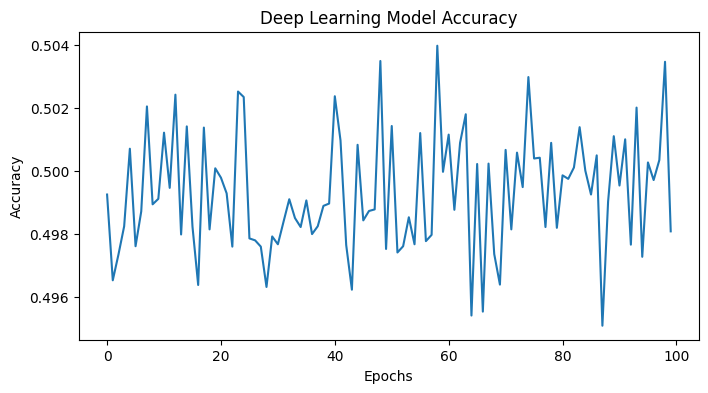

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(history.history['accuracy'])

plt.title("Deep Learning Model Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.show()

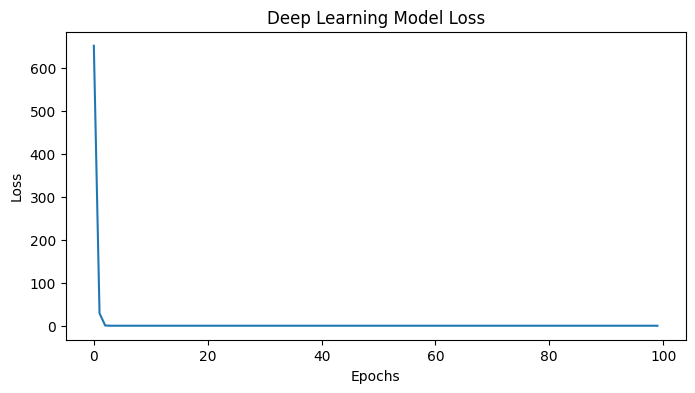

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(history.history['loss'])

plt.title("Deep Learning Model Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

# Conclusion

This project successfully developed an **AI-Powered Employee Attrition Prediction System** using both **Machine Learning** and **Deep Learning** techniques to predict whether an employee is likely to stay or leave an organization based on demographic, professional, and workplace-related factors. Since the target variable `Attrition` contains two classes (`Stayed` and `Left`), the problem was treated as a **Binary Classification** task under **Supervised Learning**. Various preprocessing techniques such as **Label Encoding, SMOTE oversampling, feature scaling, outlier removal, and exploratory data analysis** were applied to improve data quality and model performance.

Several Machine Learning models including **Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, Support Vector Machine (SVM), and XGBoost** were implemented and evaluated along with a **Deep Learning model** developed using **TensorFlow** and **Keras**. In addition, **K-Fold Cross Validation** was applied to improve model reliability and performance evaluation. Among all the models tested, the **Gradient Boosting Classifier** achieved the highest accuracy of **50.91%**, followed closely by **XGBoost** and **SVM**. The results indicate that employee attrition prediction is a complex problem influenced by multiple factors, making accurate prediction more challenging compared to simpler classification tasks. Overall, this project demonstrates the potential of Artificial Intelligence, Machine Learning, and Generative AI techniques in helping organizations analyze workforce trends, identify potential attrition risks, and support data-driven human resource decision-making strategies.